# Netflix EDA - Basic
Tools: pandas + matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
df = pd.read_csv('netflix_titles.csv')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 8807
Columns: 12


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,TV Show Title 2368,NaN,"Actor 246, Actor 79, Actor 233, Actor 275","Mexico, Australia","August 28, 2016",2013,TV-MA,90 min,"Children & Family Movies, Reality TV",Description for title 1.
1,s2,Movie,TV Show Title 330,NaN,NaN,"France, United Kingdom","November 29, 2011",1976,PG,115 min,"Reality TV, Dramas",Description for title 2.
2,s3,Movie,TV Show Title 1993,NaN,"Actor 199, Actor 238, Actor 187, Actor 173",Brazil,"January 08, 2017",1969,TV-14,113 min,"Horror Movies, Documentaries, Romantic Movies",Description for title 3.
3,s4,TV Show,Movie Title 1845,NaN,"Actor 210, Actor 192, Actor 158, Actor 110, Ac...",Canada,"November 20, 2019",2006,TV-MA,4 Seasons,Reality TV,Description for title 4.
4,s5,Movie,Movie Title 1082,NaN,"Actor 93, Actor 227, Actor 13, Actor 106","South Korea, United States, Canada","September 26, 2014",1997,R,130 min,Horror Movies,Description for title 5.


## 2. Basic Info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      1453 non-null   str  
 4   cast          8366 non-null   str  
 5   country       8367 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8616 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,1983.664017
std,22.736028
min,1940.000000
25%,1965.000000
50%,1985.000000
75%,2003.000000
max,2021.000000


## 3. Missing Values

In [6]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        7354
cast             441
country          440
date_added         0
release_year       0
rating           191
duration           0
listed_in          0
description        0
dtype: int64


In [7]:
# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['rating']   = df['rating'].fillna('NR')

print('After cleaning:')
print(df.isnull().sum())

After cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


## 4. Movies vs TV Shows

In [8]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


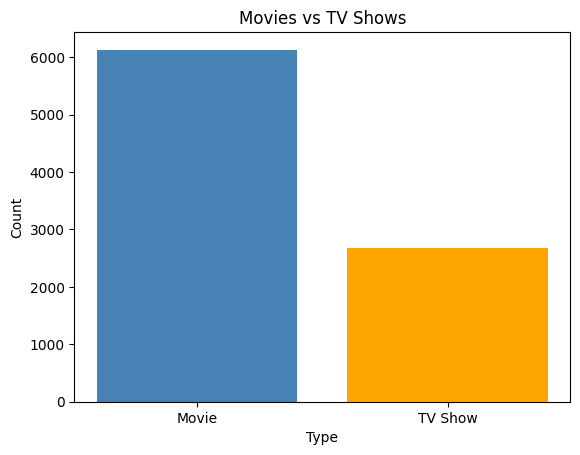

In [9]:
plt.bar(type_counts.index, type_counts.values, color=['steelblue', 'orange'])
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

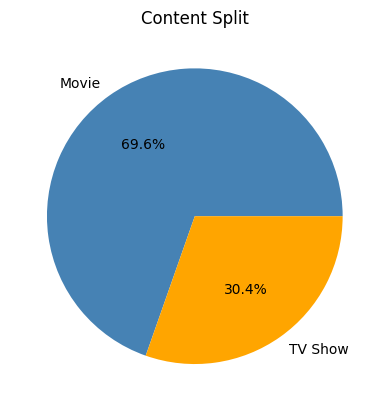

In [10]:
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['steelblue','orange'])
plt.title('Content Split')
plt.show()

## 5. Top Ratings

In [11]:
rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA    3088
TV-14    1856
TV-PG     755
R         714
PG-13     629
TV-Y7     400
NR        345
PG        333
TV-G      234
G         176
NC-17      99
UR         93
TV-Y       85
Name: count, dtype: int64


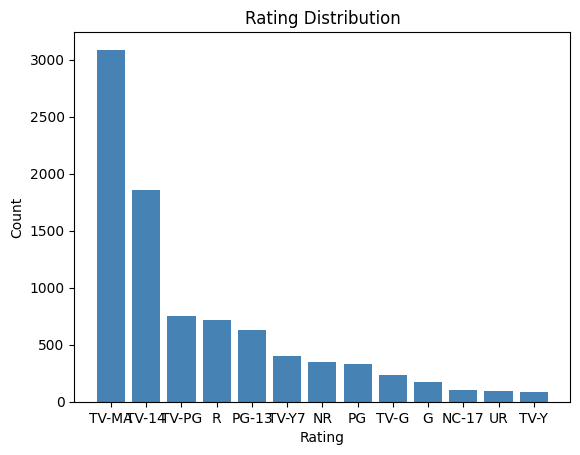

In [12]:
plt.bar(rating_counts.index, rating_counts.values, color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## 6. Release Year

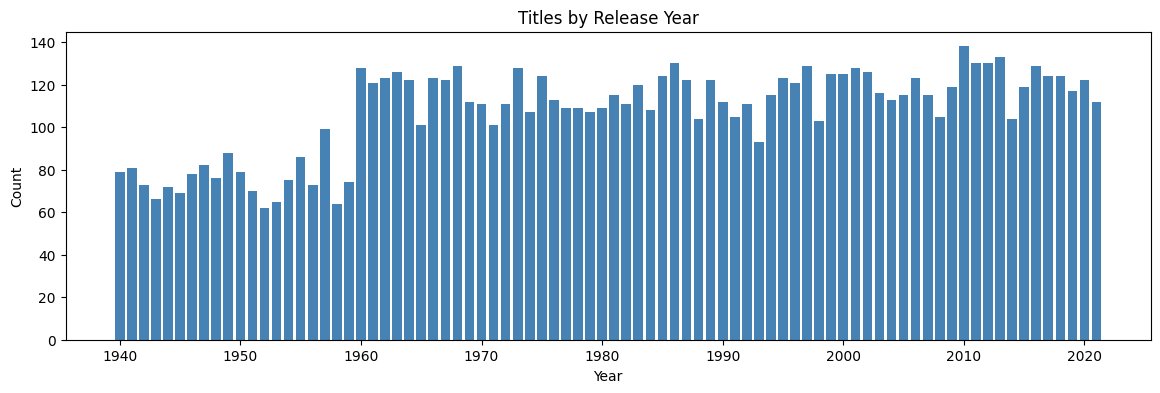

In [13]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(14, 4))
plt.bar(year_counts.index, year_counts.values, color='steelblue')
plt.title('Titles by Release Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

## 7. Top 10 Countries

In [14]:
all_countries = df['country'].str.split(', ').explode().str.strip()
all_countries = all_countries[all_countries != 'Unknown']
top_countries = all_countries.value_counts().head(10)
print(top_countries)

country
Nigeria          1165
Italy            1157
Mexico           1134
Canada           1134
Australia        1132
Spain            1127
India            1120
Turkey           1117
South Korea      1114
United States    1112
Name: count, dtype: int64


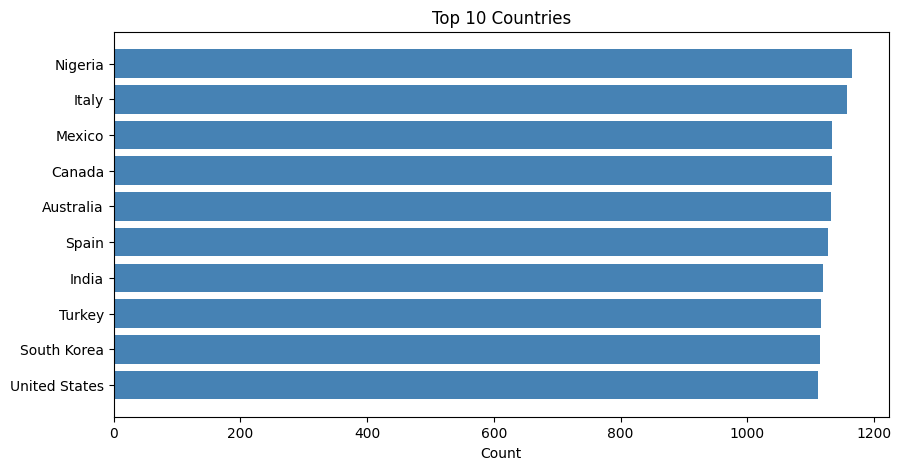

In [15]:
plt.figure(figsize=(10, 5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue')
plt.title('Top 10 Countries')
plt.xlabel('Count')
plt.show()

## 8. Top 10 Genres

In [16]:
all_genres = df['listed_in'].str.split(', ').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
print(top_genres)

listed_in
Comedies                1211
International Movies    1205
Stand-Up Comedy         1195
Documentaries           1194
Reality TV              1193
Action & Adventure      1190
Dramas                  1188
Kids TV                 1188
Romantic Movies         1178
Crime TV Shows          1163
Name: count, dtype: int64


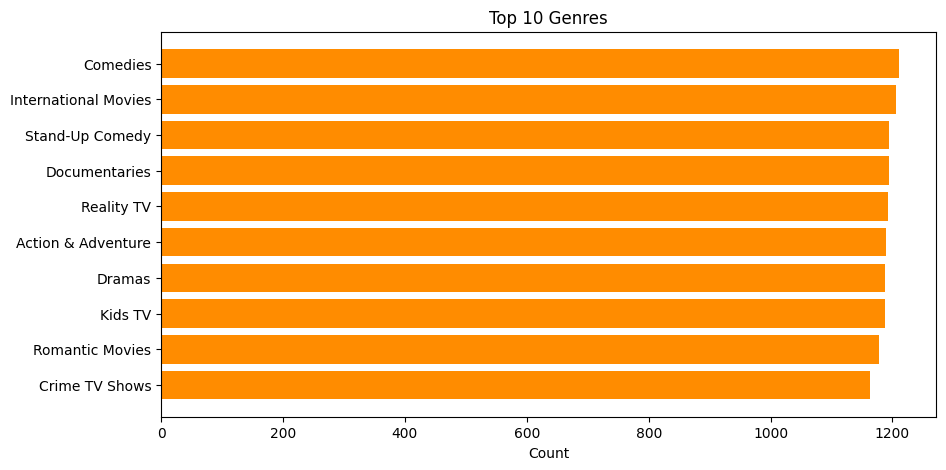

In [17]:
plt.figure(figsize=(10, 5))
plt.barh(top_genres.index[::-1], top_genres.values[::-1], color='darkorange')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.show()

## 9. Movie Duration

In [18]:
# Extract minutes from duration column for movies only
movie_mask = df['type'] == 'Movie'
df.loc[movie_mask, 'duration_min'] = (
    df.loc[movie_mask, 'duration']
    .str.replace(' min', '', regex=False)
    .astype(float)
)

movies_df = df[df['type'] == 'Movie'].dropna(subset=['duration_min'])
print('Average duration:', round(movies_df['duration_min'].mean(), 1), 'min')
print('Max duration    :', movies_df['duration_min'].max(), 'min')
print('Min duration    :', movies_df['duration_min'].min(), 'min')

Average duration: 119.4 min
Max duration    : 180.0 min
Min duration    : 60.0 min


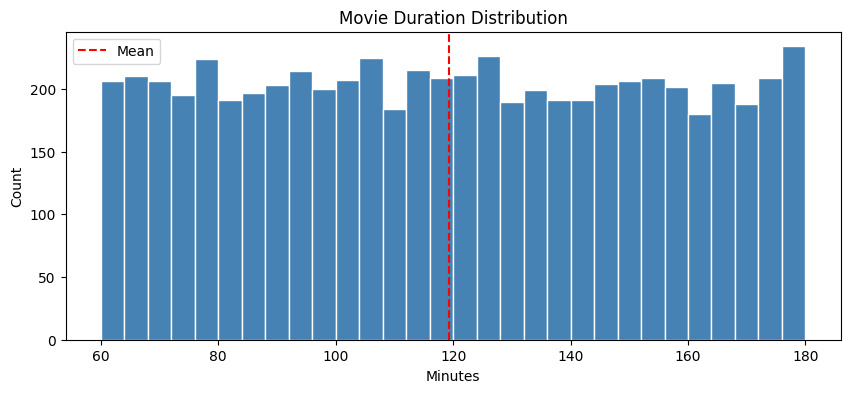

In [19]:
plt.figure(figsize=(10, 4))
plt.hist(movies_df['duration_min'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(movies_df['duration_min'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Movie Duration Distribution')
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.legend()
plt.show()

## 10. Summary

In [20]:
print('Total titles  :', len(df))
print('Movies        :', (df['type'] == 'Movie').sum())
print('TV Shows      :', (df['type'] == 'TV Show').sum())
print('Top rating    :', df['rating'].value_counts().idxmax())
print('Top country   :', all_countries.value_counts().idxmax())
print('Top genre     :', all_genres.value_counts().idxmax())
print('Avg movie dur :', round(movies_df['duration_min'].mean(), 1), 'min')

Total titles  : 8807
Movies        : 6131
TV Shows      : 2676
Top rating    : TV-MA
Top country   : Nigeria
Top genre     : Comedies
Avg movie dur : 119.4 min
